# Handling Outliers

## Machine Learning Journey

**Topic 04: Handling Outliers**

### Techniques Covered

- IQR Method
- Z-Score Method
- Outlier Detection
- Outlier Removal
- Box Plot Visualization

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import zscore

In [2]:
df = pd.read_csv("../datasets/04_outliers.csv")

df

,id,age,salary,experience
0,1,22,25000,1
1,2,25,30000,2
2,3,28,35000,3
3,4,30,40000,5
4,5,32,45000,6
5,6,35,50000,8
6,7,38,55000,10
7,8,40,60000,12
8,9,42,65000,15
9,10,45,300000,18


# IQR Method

The Interquartile Range (IQR) method detects outliers using the first quartile (Q1) and third quartile (Q3).

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

In [3]:
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 38750.0
Q3: 66250.0
IQR: 27500.0
Lower Bound: -2500.0
Upper Bound: 107500.0


In [4]:
outliers = df[
    (df["salary"] < lower_bound) |
    (df["salary"] > upper_bound)
]

print("Outliers:")
outliers

Outliers:


,id,age,salary,experience
9,10,45,300000,18


# Removing Outliers using IQR

Values outside the lower and upper bounds are removed from the dataset.

In [5]:
df_iqr = df[
    (df["salary"] >= lower_bound) &
    (df["salary"] <= upper_bound)
]

df_iqr

,id,age,salary,experience
0,1,22,25000,1
1,2,25,30000,2
2,3,28,35000,3
3,4,30,40000,5
4,5,32,45000,6
5,6,35,50000,8
6,7,38,55000,10
7,8,40,60000,12
8,9,42,65000,15
10,11,48,70000,20


# Z-Score Method

Z-Score measures how far a data point is from the mean in terms of standard deviations.

Generally:

|Z| > 3 → Outlier

In [6]:
df["z_score"] = zscore(df["salary"])

df[["salary", "z_score"]]

,salary,z_score
0,25000,-0.647956
1,30000,-0.577270
2,35000,-0.506584
3,40000,-0.435898
4,45000,-0.365212
5,50000,-0.294526
6,55000,-0.223839
7,60000,-0.153153
8,65000,-0.082467
9,300000,3.239781


In [7]:
z_score_outliers = df[
    abs(df["z_score"]) > 3
]

print("Outliers using Z-Score:")
z_score_outliers

Outliers using Z-Score:


,id,age,salary,experience,z_score
9,10,45,300000,18,3.239781


# Box Plot Visualization

A box plot helps visualize the distribution of data and identify potential outliers.

- Box → Q1 to Q3
- Middle line → Median
- Whiskers → Normal range
- Points outside whiskers → Potential outliers

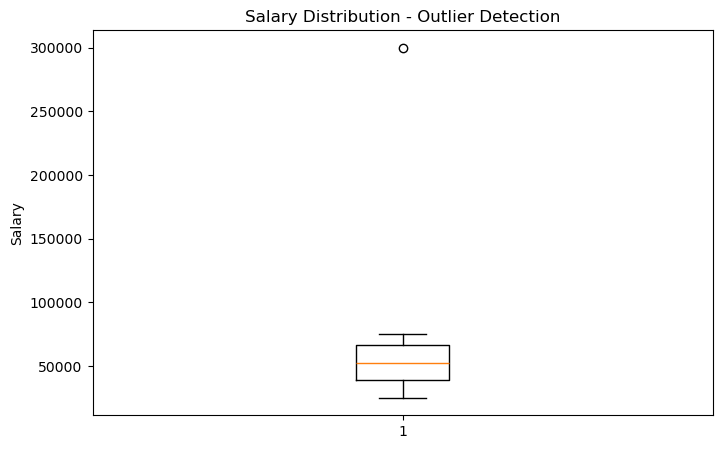

In [9]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["salary"])

plt.title("Salary Distribution - Outlier Detection")
plt.ylabel("Salary")

plt.show()

# Conclusion

In this notebook, we learned how to detect and handle outliers using:

- IQR Method
- Z-Score Method
- Box Plot Visualization

Outlier handling helps improve the quality of data and can improve Machine Learning model performance.